# Financial Tweets Analysis with Apache Beam

This notebook demonstrates Apache Beam pipelines for analyzing financial tweets data.

**Dataset Files:**
- `stockerbot-export` - Raw tweet data
- `stocks_cleaned` - Cleaned stock data

**Learning Objectives:**
1. Understand Apache Beam's programming model
2. Build multiple data processing pipelines
3. Extract insights from financial social media data
4. Practice MLOps concepts (data pipelines, reproducibility)

## Setup and Installation

In [1]:
%pip install apache-beam --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\Sushmitha Sudharsan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [21]:
import apache_beam as beam
import re
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Explore the Data

Let's first understand what's in our data files.

In [17]:
# Define your file paths - Simple relative paths since we're in Apache_Beam_Labs folder
DATA_DIR = 'data'
TWEETS_FILE = os.path.join('data', 'stockerbot-export.csv')
STOCKS_FILE = os.path.join('data', 'stocks_cleaned.csv')
OUTPUT_DIR = 'outputs'

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✓ Libraries imported successfully")
print(f"✓ Output directory: {OUTPUT_DIR}")

✓ Libraries imported successfully
✓ Output directory: outputs


In [18]:
# ============================================================================
# CELL 2: Explore Your Data Files
# ============================================================================

# Check if your data files exist
files = [TWEETS_FILE, STOCKS_FILE]

print("\nChecking for data files...")
for file in files:
    if os.path.exists(file):
        size = os.path.getsize(file) / (1024 * 1024)  # MB
        print(f"✓ Found: {file}")
        print(f"  Size: {size:.2f} MB")
    else:
        print(f"✗ Not found: {file}")

# Preview the stockerbot-export data
print("\n" + "="*80)
print("STOCKERBOT-EXPORT Preview (first 3 lines):")
print("="*80)
try:
    with open(TWEETS_FILE, 'r', encoding='utf-8', errors='ignore') as f:
        for i, line in enumerate(f):
            if i < 3:
                print(f"Line {i+1}: {line[:150]}...")
            else:
                break
except FileNotFoundError:
    print("File not found. Please check the path.")

# Try to read as CSV to see column structure
print("\n" + "="*80)
print("CSV Structure Analysis:")
print("="*80)
try:
    df_tweets = pd.read_csv(TWEETS_FILE, nrows=5)
    print(f"\nColumns in stockerbot-export.csv: {df_tweets.columns.tolist()}")
    print(f"Shape: {df_tweets.shape}")
    print("\nFirst few rows:")
    print(df_tweets.head())
except Exception as e:
    print(f"Could not read as CSV: {e}")
    print("Will treat as plain text file")

try:
    df_stocks = pd.read_csv(STOCKS_FILE, nrows=5)
    print(f"\n\nColumns in stocks_cleaned.csv: {df_stocks.columns.tolist()}")
    print(f"Shape: {df_stocks.shape}")
    print("\nFirst few rows:")
    print(df_stocks.head())
except Exception as e:
    print(f"Could not read stocks_cleaned.csv: {e}")


Checking for data files...
✓ Found: data\stockerbot-export.csv
  Size: 6.94 MB
✓ Found: data\stocks_cleaned.csv
  Size: 0.01 MB

STOCKERBOT-EXPORT Preview (first 3 lines):
Line 1: id,text,timestamp,source,symbols,company_names,url,verified
...
Line 2: 1019696670777503700,VIDEO: “I was in my office. I was minding my own business...” –David Solomon tells $GS interns how he learned he wa… https://t.co/...
Line 3: 1019709091038548000,The price of lumber $LB_F is down 22% since hitting its YTD highs. The Macy's $M turnaround is still happening.… https://t.co/XnKs...

CSV Structure Analysis:

Columns in stockerbot-export.csv: ['id', 'text', 'timestamp', 'source', 'symbols', 'company_names', 'url', 'verified']
Shape: (5, 8)

First few rows:
                    id                                               text  \
0  1019696670777503700  VIDEO: “I was in my office. I was minding my o...   
1  1019709091038548000  The price of lumber $LB_F is down 22% since hi...   
2  1019711413798035500  

In [19]:
# ============================================================================
# CELL 3: Define Custom Transformations (DoFn Classes)
# ============================================================================

class ExtractStockTickers(beam.DoFn):
    """Extract stock ticker symbols from text (format: $TICKER)"""
    def process(self, line):
        if not line or len(line.strip()) == 0:
            return
        try:
            # Find all stock tickers in format $TICKER
            tickers = re.findall(r'\$[A-Z]{1,5}(?![A-Z])', line)
            for ticker in tickers:
                yield (ticker, 1)
        except:
            pass

class AnalyzeSentiment(beam.DoFn):
    """Categorize text based on financial sentiment keywords"""
    
    POSITIVE_WORDS = {
        'bull', 'bullish', 'gain', 'profit', 'rally', 'surge', 
        'up', 'rise', 'growth', 'strong', 'outperform', 'buy',
        'moon', 'rocket', 'breakthrough', 'beat', 'soar', 'climb',
        'higher', 'positive', 'optimistic', 'winning'
    }
    
    NEGATIVE_WORDS = {
        'bear', 'bearish', 'loss', 'drop', 'fall', 'decline',
        'down', 'weak', 'underperform', 'sell', 'crash', 'plunge',
        'tank', 'dump', 'miss', 'sink', 'tumble', 'warning',
        'lower', 'negative', 'pessimistic', 'losing'
    }
    
    def process(self, line):
        if not line or len(line.strip()) == 0:
            return
        try:
            text_lower = line.lower()
            pos_count = sum(1 for word in self.POSITIVE_WORDS if word in text_lower)
            neg_count = sum(1 for word in self.NEGATIVE_WORDS if word in text_lower)
            
            if pos_count > neg_count:
                sentiment = 'Positive'
            elif neg_count > pos_count:
                sentiment = 'Negative'
            else:
                sentiment = 'Neutral'
            
            yield (sentiment, 1)
        except:
            pass

class ExtractHashtags(beam.DoFn):
    """Extract hashtags from text"""
    def process(self, line):
        if not line or len(line.strip()) == 0:
            return
        try:
            hashtags = re.findall(r'#\w+', line)
            for hashtag in hashtags:
                yield (hashtag.lower(), 1)
        except:
            pass

class ExtractTickerPairs(beam.DoFn):
    """Extract pairs of tickers mentioned in the same line"""
    def process(self, line):
        if not line or len(line.strip()) == 0:
            return
        try:
            tickers = re.findall(r'\$[A-Z]{1,5}(?![A-Z])', line)
            tickers = list(set(tickers))
            
            if len(tickers) >= 2:
                for i in range(len(tickers)):
                    for j in range(i+1, len(tickers)):
                        pair = tuple(sorted([tickers[i], tickers[j]]))
                        yield (pair, 1)
        except:
            pass

class ExtractTickerWithSentiment(beam.DoFn):
    """Extract ticker and sentiment from same line"""
    
    POSITIVE_WORDS = {
        'bull', 'bullish', 'gain', 'profit', 'rally', 'surge', 
        'up', 'rise', 'growth', 'strong', 'outperform', 'buy',
        'moon', 'rocket', 'breakthrough', 'beat', 'soar', 'climb'
    }
    
    NEGATIVE_WORDS = {
        'bear', 'bearish', 'loss', 'drop', 'fall', 'decline',
        'down', 'weak', 'underperform', 'sell', 'crash', 'plunge',
        'tank', 'dump', 'miss', 'sink', 'tumble', 'warning'
    }
    
    def process(self, line):
        if not line or len(line.strip()) == 0:
            return
        try:
            tickers = re.findall(r'\$[A-Z]{1,5}(?![A-Z])', line)
            if not tickers:
                return
            
            text_lower = line.lower()
            pos_count = sum(1 for word in self.POSITIVE_WORDS if word in text_lower)
            neg_count = sum(1 for word in self.NEGATIVE_WORDS if word in text_lower)
            
            if pos_count > neg_count:
                sentiment = 'Positive'
            elif neg_count > pos_count:
                sentiment = 'Negative'
            else:
                sentiment = 'Neutral'
            
            for ticker in set(tickers):
                yield ((ticker, sentiment), 1)
        except:
            pass

print("✓ All transformation classes defined")

✓ All transformation classes defined


In [22]:
# ============================================================================
# CELL 4: Pipeline 1 - Stock Ticker Mentions
# ============================================================================

print("Running Pipeline 1: Stock Ticker Mentions...\n")

output_path = os.path.join(OUTPUT_DIR, '01_ticker_mentions')

with beam.Pipeline() as pipeline:
    ticker_counts = (
        pipeline
        | 'Read Tweets' >> beam.io.ReadFromText(TWEETS_FILE)
        | 'Extract Tickers' >> beam.ParDo(ExtractStockTickers())
        | 'Count Per Ticker' >> beam.CombinePerKey(sum)
        | 'Format Results' >> beam.Map(
            lambda x: f"{x[0]}: {x[1]} mentions"
        )
        | 'Write to File' >> beam.io.WriteToText(
            output_path,
            file_name_suffix='.txt'
        )
    )

print("✓ Pipeline 1 completed!")
print(f"Results: {output_path}-00000-of-00001.txt\n")

# View top 20 results
print("="*80)
print("TOP 20 MOST MENTIONED STOCK TICKERS:")
print("="*80)
output_files = glob.glob(f'{output_path}*.txt')
if output_files:
    with open(output_files[0], 'r') as f:
        lines = f.readlines()
        for i, line in enumerate(lines[:20], 1):
            print(f"{i:2d}. {line.strip()}")
else:
    print("No results found. Check if the pipeline ran successfully.")


Running Pipeline 1: Stock Ticker Mentions...



✓ Pipeline 1 completed!
Results: outputs\01_ticker_mentions-00000-of-00001.txt

TOP 20 MOST MENTIONED STOCK TICKERS:
 1. $GS: 316 mentions
 2. $LB: 45 mentions
 3. $M: 79 mentions
 4. $GOOGL: 277 mentions
 5. $FIS: 56 mentions
 6. $AJG: 81 mentions
 7. $MMC: 8 mentions
 8. $INFO: 69 mentions
 9. $C: 245 mentions
10. $NEW: 22 mentions
11. $FLR: 65 mentions
12. $AVY: 53 mentions
13. $PEP: 77 mentions
14. $FST: 3 mentions
15. $XYL: 40 mentions
16. $IRM: 85 mentions
17. $ORLY: 74 mentions
18. $AVB: 25 mentions
19. $CUBE: 18 mentions
20. $EXR: 79 mentions


In [23]:
# ============================================================================
# CELL 5: Pipeline 2 - Sentiment Analysis
# ============================================================================

print("\nRunning Pipeline 2: Sentiment Analysis...\n")

output_path = os.path.join(OUTPUT_DIR, '02_sentiment_analysis')

with beam.Pipeline() as pipeline:
    sentiment_counts = (
        pipeline
        | 'Read Tweets' >> beam.io.ReadFromText(TWEETS_FILE)
        | 'Analyze Sentiment' >> beam.ParDo(AnalyzeSentiment())
        | 'Count Sentiments' >> beam.CombinePerKey(sum)
        | 'Format Results' >> beam.Map(
            lambda x: f"{x[0]}: {x[1]} tweets"
        )
        | 'Write Results' >> beam.io.WriteToText(
            output_path,
            file_name_suffix='.txt'
        )
    )

print("✓ Pipeline 2 completed!")
print(f"Results: {output_path}-00000-of-00001.txt\n")

# View results
print("="*80)
print("SENTIMENT DISTRIBUTION:")
print("="*80)
output_files = glob.glob(f'{output_path}*.txt')
if output_files:
    with open(output_files[0], 'r') as f:
        for line in f:
            print(line.strip())



Running Pipeline 2: Sentiment Analysis...

✓ Pipeline 2 completed!
Results: outputs\02_sentiment_analysis-00000-of-00001.txt

SENTIMENT DISTRIBUTION:
Neutral: 18164 tweets
Negative: 3010 tweets
Positive: 7701 tweets


In [24]:
# ============================================================================
# CELL 6: Pipeline 3 - Hashtag Trends
# ============================================================================

print("\nRunning Pipeline 3: Hashtag Analysis...\n")

output_path = os.path.join(OUTPUT_DIR, '03_hashtag_trends')

with beam.Pipeline() as pipeline:
    hashtag_counts = (
        pipeline
        | 'Read Tweets' >> beam.io.ReadFromText(TWEETS_FILE)
        | 'Extract Hashtags' >> beam.ParDo(ExtractHashtags())
        | 'Count Hashtags' >> beam.CombinePerKey(sum)
        | 'Format Results' >> beam.Map(
            lambda x: f"{x[0]}: {x[1]} uses"
        )
        | 'Write Results' >> beam.io.WriteToText(
            output_path,
            file_name_suffix='.txt'
        )
    )

print("✓ Pipeline 3 completed!")
print(f"Results: {output_path}-00000-of-00001.txt\n")

# View top 15 results
print("="*80)
print("TOP 15 TRENDING HASHTAGS:")
print("="*80)
output_files = glob.glob(f'{output_path}*.txt')
if output_files:
    with open(output_files[0], 'r') as f:
        lines = f.readlines()
        for i, line in enumerate(lines[:15], 1):
            print(f"{i:2d}. {line.strip()}")



Running Pipeline 3: Hashtag Analysis...

✓ Pipeline 3 completed!
Results: outputs\03_hashtag_trends-00000-of-00001.txt

TOP 15 TRENDING HASHTAGS:
 1. #paid: 1 uses
 2. #realmoneysod: 15 uses
 3. #bullmarket: 1 uses
 4. #book: 28 uses
 5. #wallstreet: 55 uses
 6. #maxpain: 632 uses
 7. #options: 651 uses
 8. #winners: 14 uses
 9. #nojoke: 1 uses
10. #jobs: 1 uses
11. #opening: 1 uses
12. #tungsten: 3 uses
13. #mines: 1 uses
14. #health: 12 uses
15. #blockchain: 61 uses


In [25]:
# ============================================================================
# CELL 7: Pipeline 4 - Ticker Co-occurrence
# ============================================================================

print("\nRunning Pipeline 4: Ticker Co-occurrence...\n")

output_path = os.path.join(OUTPUT_DIR, '04_ticker_cooccurrence')

with beam.Pipeline() as pipeline:
    ticker_pairs = (
        pipeline
        | 'Read Tweets' >> beam.io.ReadFromText(TWEETS_FILE)
        | 'Extract Ticker Pairs' >> beam.ParDo(ExtractTickerPairs())
        | 'Count Pairs' >> beam.CombinePerKey(sum)
        | 'Format Results' >> beam.Map(
            lambda x: f"{x[0][0]} & {x[0][1]}: {x[1]} times together"
        )
        | 'Write Results' >> beam.io.WriteToText(
            output_path,
            file_name_suffix='.txt'
        )
    )

print("✓ Pipeline 4 completed!")
print(f"Results: {output_path}-00000-of-00001.txt\n")

# View top 20 results
print("="*80)
print("TOP 20 TICKER PAIRS MENTIONED TOGETHER:")
print("="*80)
output_files = glob.glob(f'{output_path}*.txt')
if output_files:
    with open(output_files[0], 'r') as f:
        lines = f.readlines()
        for i, line in enumerate(lines[:20], 1):
            print(f"{i:2d}. {line.strip()}")



Running Pipeline 4: Ticker Co-occurrence...

✓ Pipeline 4 completed!
Results: outputs\04_ticker_cooccurrence-00000-of-00001.txt

TOP 20 TICKER PAIRS MENTIONED TOGETHER:
 1. $LB & $M: 9 times together
 2. $AJG & $MMC: 6 times together
 3. $C & $INFO: 1 times together
 4. $FLR & $NEW: 21 times together
 5. $FST & $PEP: 3 times together
 6. $LSI & $PSA: 3 times together
 7. $CUBE & $LSI: 3 times together
 8. $EXR & $LSI: 4 times together
 9. $IRM & $LSI: 3 times together
10. $HOG & $LSI: 3 times together
11. $KO & $LSI: 3 times together
12. $CUBE & $PSA: 4 times together
13. $EXR & $PSA: 4 times together
14. $IRM & $PSA: 3 times together
15. $HOG & $PSA: 3 times together
16. $KO & $PSA: 4 times together
17. $CUBE & $EXR: 4 times together
18. $CUBE & $IRM: 3 times together
19. $CUBE & $HOG: 3 times together
20. $CUBE & $KO: 3 times together


In [26]:
# ============================================================================
# CELL 8: Pipeline 5 - Advanced: Ticker + Sentiment Combined
# ============================================================================

print("\nRunning Pipeline 5: Ticker Sentiment Breakdown...\n")

output_path = os.path.join(OUTPUT_DIR, '05_ticker_sentiment')

with beam.Pipeline() as pipeline:
    ticker_sentiment = (
        pipeline
        | 'Read Tweets' >> beam.io.ReadFromText(TWEETS_FILE)
        | 'Extract Ticker+Sentiment' >> beam.ParDo(ExtractTickerWithSentiment())
        | 'Count Combinations' >> beam.CombinePerKey(sum)
        | 'Format Results' >> beam.Map(
            lambda x: f"{x[0][0]} - {x[0][1]}: {x[1]} mentions"
        )
        | 'Write Results' >> beam.io.WriteToText(
            output_path,
            file_name_suffix='.txt'
        )
    )

print("✓ Pipeline 5 completed!")
print(f"Results: {output_path}-00000-of-00001.txt\n")



Running Pipeline 5: Ticker Sentiment Breakdown...

✓ Pipeline 5 completed!
Results: outputs\05_ticker_sentiment-00000-of-00001.txt



In [27]:
# View sample results
print("="*80)
print("TICKER SENTIMENT BREAKDOWN (Top 30):")
print("="*80)
output_files = glob.glob(f'{output_path}*.txt')
if output_files:
    with open(output_files[0], 'r') as f:
        lines = f.readlines()
        for i, line in enumerate(lines[:30], 1):
            print(f"{i:2d}. {line.strip()}")


TICKER SENTIMENT BREAKDOWN (Top 30):
 1. $GS - Neutral: 256 mentions
 2. $LB - Negative: 13 mentions
 3. $M - Negative: 10 mentions
 4. $GOOGL - Positive: 67 mentions
 5. $FIS - Positive: 9 mentions
 6. $MMC - Neutral: 7 mentions
 7. $AJG - Neutral: 59 mentions
 8. $INFO - Neutral: 42 mentions
 9. $C - Neutral: 122 mentions
10. $FLR - Positive: 13 mentions
11. $NEW - Positive: 2 mentions
12. $AVY - Neutral: 41 mentions
13. $FST - Neutral: 3 mentions
14. $PEP - Neutral: 45 mentions
15. $XYL - Neutral: 23 mentions
16. $IRM - Neutral: 62 mentions
17. $ORLY - Neutral: 49 mentions
18. $AVB - Neutral: 19 mentions
19. $LSI - Positive: 4 mentions
20. $PSA - Positive: 15 mentions
21. $CUBE - Positive: 4 mentions
22. $EXR - Positive: 28 mentions
23. $IRM - Positive: 15 mentions
24. $HOG - Positive: 5 mentions
25. $KO - Positive: 27 mentions
26. $CXO - Neutral: 32 mentions
27. $HP - Neutral: 54 mentions
28. $RSPP - Neutral: 16 mentions
29. $MOS - Neutral: 50 mentions
30. $XRX - Neutral: 49 mentio

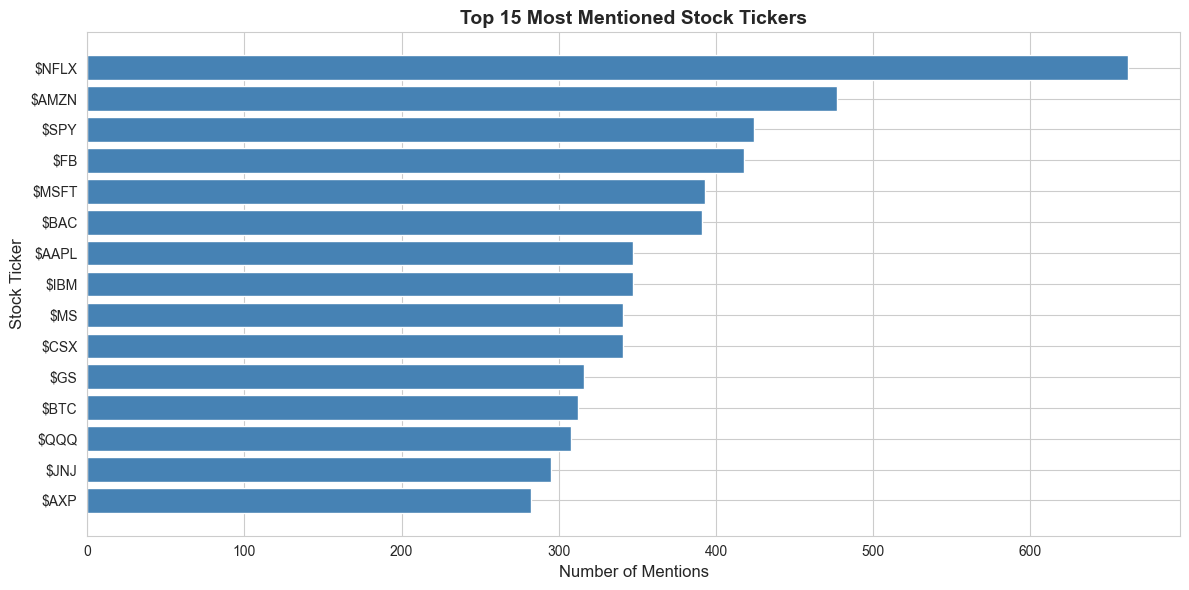

In [28]:
# ============================================================================
# CELL 9: Visualize Results
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Parse ticker data
ticker_data = []
output_files = glob.glob(os.path.join(OUTPUT_DIR, '01_ticker_mentions*.txt'))
if output_files:
    with open(output_files[0], 'r') as f:
        for line in f:
            parts = line.strip().split(': ')
            if len(parts) == 2:
                ticker = parts[0]
                count = int(parts[1].split()[0])
                ticker_data.append({'Ticker': ticker, 'Mentions': count})

if ticker_data:
    df_tickers = pd.DataFrame(ticker_data).sort_values('Mentions', ascending=False).head(15)
    
    # Visualization 1: Top Tickers
    plt.figure(figsize=(12, 6))
    plt.barh(df_tickers['Ticker'], df_tickers['Mentions'], color='steelblue')
    plt.xlabel('Number of Mentions', fontsize=12)
    plt.ylabel('Stock Ticker', fontsize=12)
    plt.title('Top 15 Most Mentioned Stock Tickers', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("No ticker data found for visualization")

## Visualize Results with Pandas

Let's create some visualizations of our pipeline results.

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline

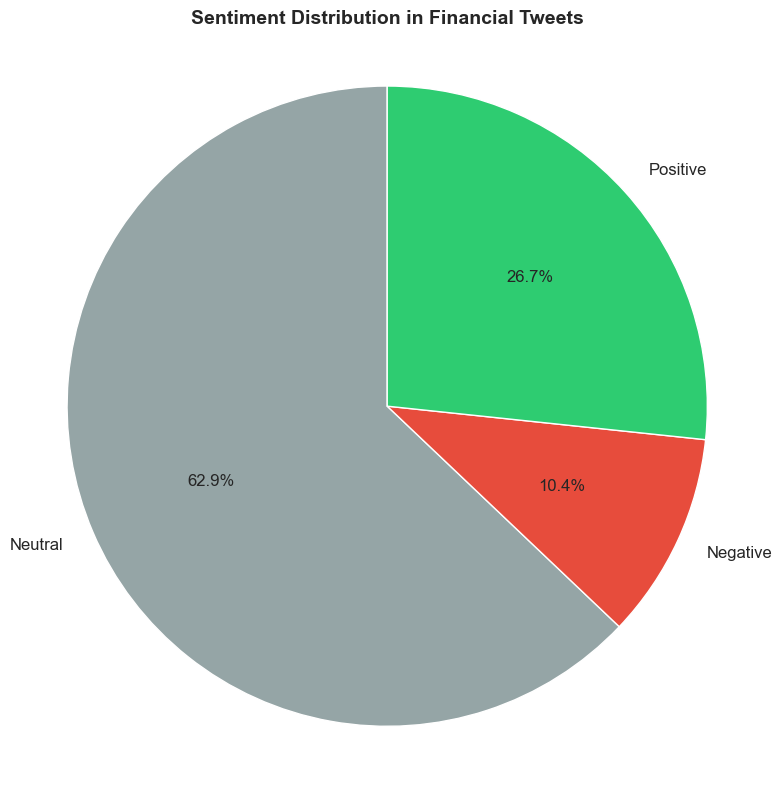

In [29]:
# Sentiment distribution pie chart
sentiment_data = []

output_files = glob.glob('outputs/02_sentiment_analysis*.txt')
if output_files:
    with open(output_files[0], 'r') as f:
        for line in f:
            parts = line.strip().split(': ')
            if len(parts) == 2:
                sentiment = parts[0]
                count = int(parts[1].split()[0])
                sentiment_data.append({'Sentiment': sentiment, 'Count': count})

df_sentiment = pd.DataFrame(sentiment_data)

colors = {'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#95a5a6'}
color_list = [colors.get(s, '#3498db') for s in df_sentiment['Sentiment']]

plt.figure(figsize=(8, 8))
plt.pie(df_sentiment['Count'], labels=df_sentiment['Sentiment'], autopct='%1.1f%%',
        startangle=90, colors=color_list, textprops={'fontsize': 12})
plt.title('Sentiment Distribution in Financial Tweets', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()